# DV ASSIGNMENT 2 (NETFLIX DATA ANALYSIS)


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
df = pd.read_csv("netflix.csv", encoding='latin1')
print(df.columns)
df.columns = df.columns.str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df = df.fillna("Unknown")
df.head()

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25 00:00:00,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


## Question 1)What is the ratio of Movies vs TV Shows on Netflix?

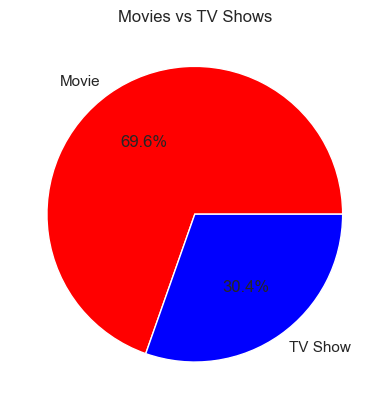

In [4]:
type_counts = df['type'].value_counts()
type_counts.plot(kind='pie', autopct='%1.1f%%', colors=['red','blue'])
plt.title("Movies vs TV Shows")
plt.ylabel('')
plt.show()

#### Insights:
#### 1. Movies dominate the platform compared to TV Shows, indicating higher investment in short-form content.
#### 2. TV Shows still hold a significant share, showing growing demand for long-form storytelling

## Question 2) Which genres are most popular on Netflix globally?
### Code+Graph:

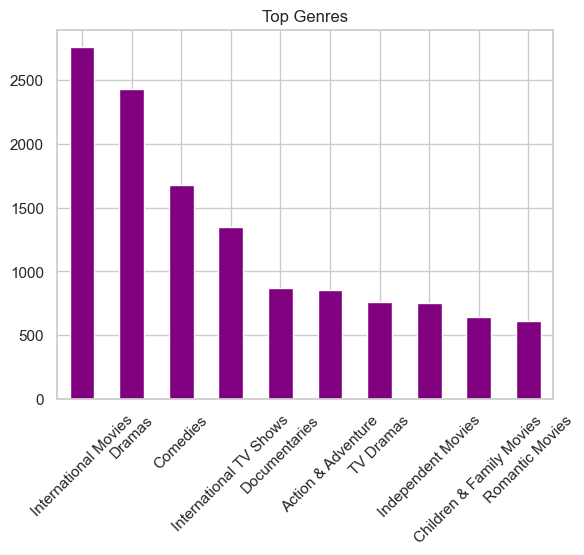

In [5]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
genres.value_counts().head(10).plot(kind='bar', color='purple')
plt.title("Top Genres")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1. Drama and International genres are usually among the most common, showing global audience preference.
#### 2. Diverse genre availability suggests Netflix targets a wide range of viewers.
## Question 3. Which years saw the highest release of content on Netflix?
### Code+Graph:

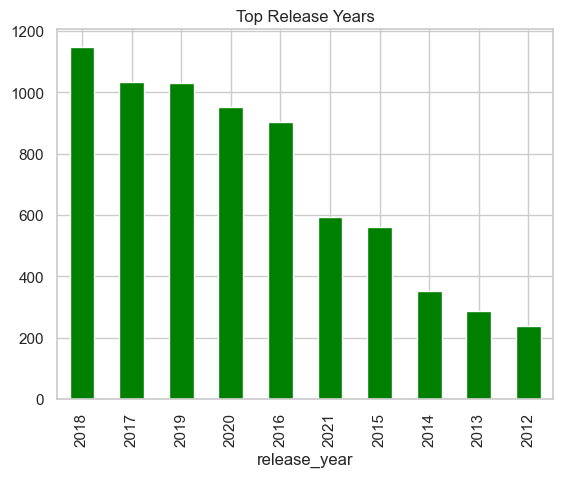

In [6]:
df['release_year'].value_counts().head(10).plot(kind='bar', color='green')
plt.title("Top Release Years")
plt.show()

### Insights:
#### 1. Recent years generally have more content, indicating rapid growth of the platform.
#### 2. Older content is less frequent, showing focus on modern and trending media.
## Question 4. Which countries produce the most Netflix content?
### code+graph:

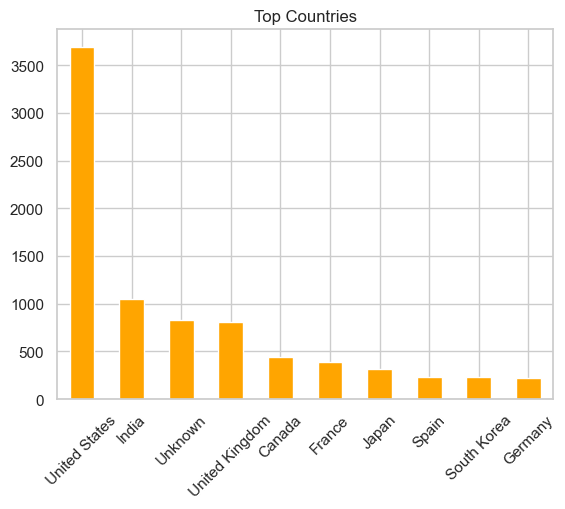

In [7]:
countries = df['country'].str.split(', ', expand=True).stack()
countries.value_counts().head(10).plot(kind='bar', color='orange')
plt.title("Top Countries")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1. The United States is usually the largest contributor of content on Netflix.
#### 2. Other countries like India and the UK are also emerging as major content producers.
## Q5. How has the trend of adding new content evolved year by year?
### Code+Graph:

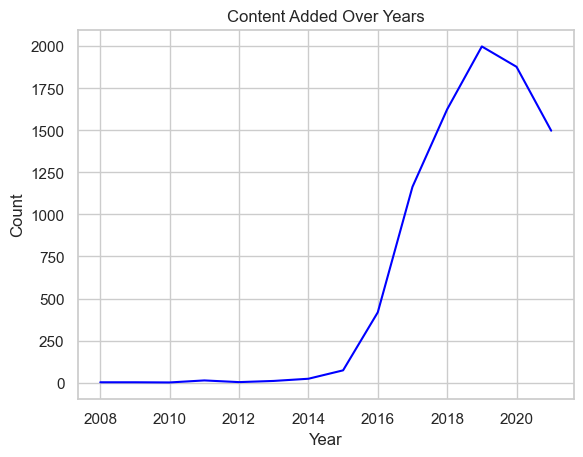

In [8]:
df['year_added'] = pd.to_numeric(df['year_added'], errors='coerce')
year_data = df['year_added'].value_counts().sort_index()
year_data.plot(color='blue')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### Insights:
#### 1. There is a steady increase in content addition over the years.
#### 2. A sharp rise in recent years indicates aggressive expansion by Netflix.
## Q6. Which ratings are most frequent on Netflix?
### Code+Graph:

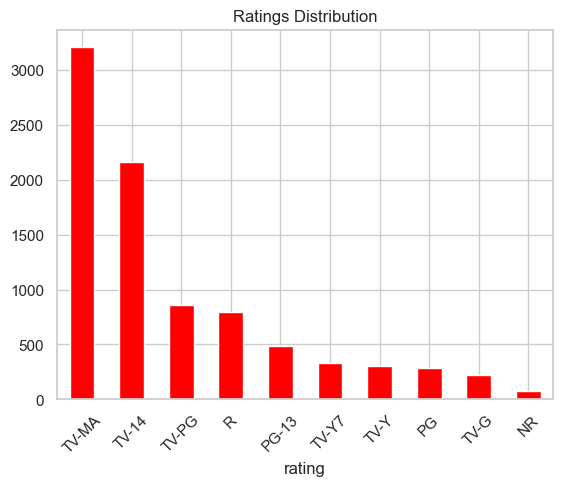

In [9]:
df['rating'].value_counts().head(10).plot(kind='bar', color='red')
plt.title("Ratings Distribution")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1.TV-MA and TV-14 ratings are often the most common, indicating mature audience targeting.
#### 2.Family-friendly content exists but is comparatively less frequent.
## Q7. Do some countries produce more mature content (TV-MA)?
### Code:

In [10]:
mature = df[df['rating'] == 'TV-MA']
mature['country'].value_counts().head(10)

country
United States     928
Unknown           276
India             248
United Kingdom    177
Spain             119
Japan              87
South Korea        85
France             80
Mexico             77
Turkey             63
Name: count, dtype: int64

### Graph :

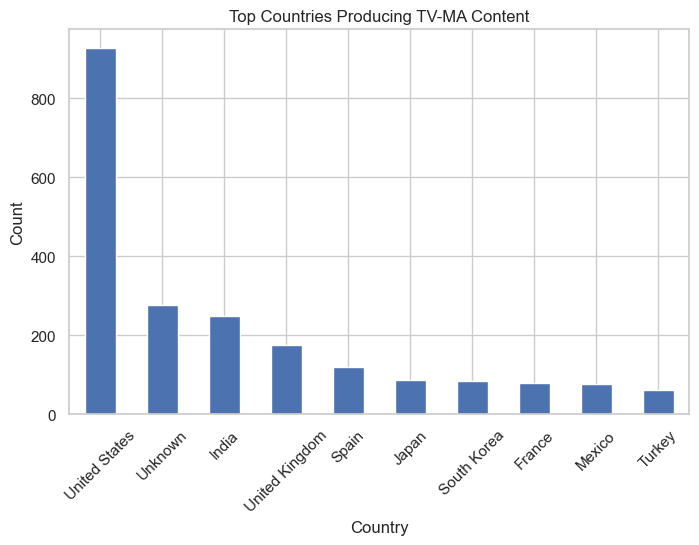

In [11]:
mature = df[df['rating'] == 'TV-MA']

mature['country'].value_counts().head(10).plot(
    kind='bar', figsize=(8,5)
)
plt.title("Top Countries Producing TV-MA Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1.Countries like the United States tend to produce more mature content.
#### 2.This helps Netflix segment content based on regional audience preferences.
## Q8. Which genres are more associated with TV Shows vs Movies?

### Code :

In [12]:
movies = df[df['type'] == 'Movie'].copy()
tv = df[df['type'] == 'TV Show'].copy()
print(movies['listed_in'].value_counts().head())
print(tv['listed_in'].value_counts().head())

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64
listed_in
Kids' TV                                             220
International TV Shows, TV Dramas                    121
Crime TV Shows, International TV Shows, TV Dramas    110
Kids' TV, TV Comedies                                 99
Reality TV                                            95
Name: count, dtype: int64


### Graph :

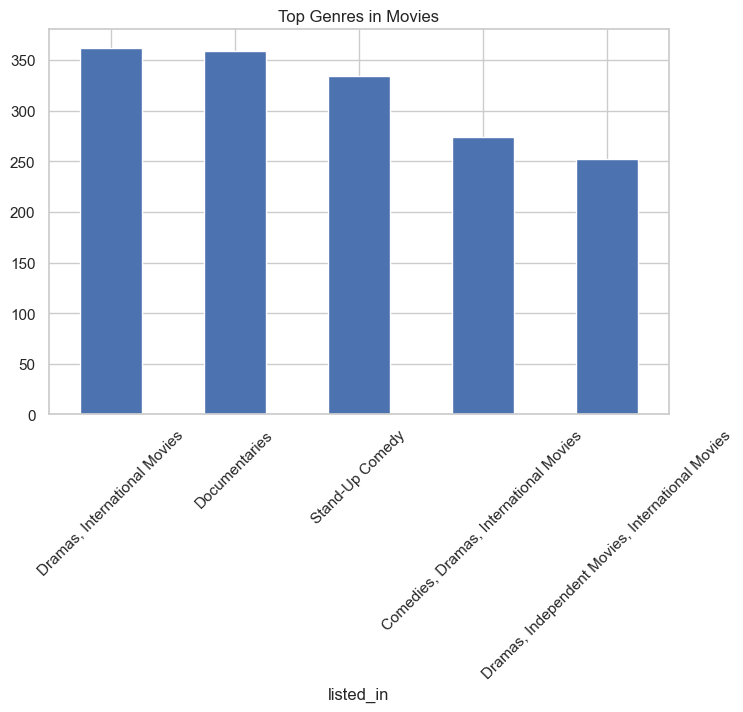

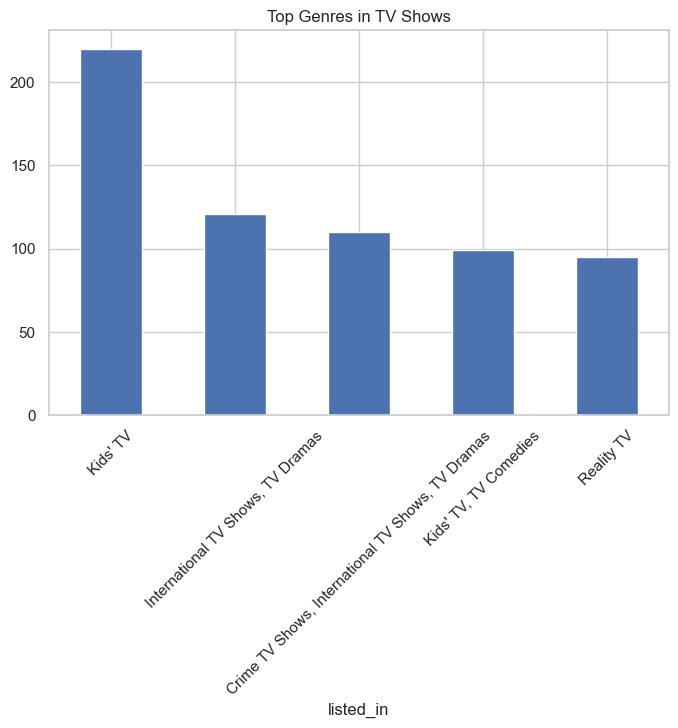

In [13]:
movies = df[df['type'] == 'Movie']
tv = df[df['type'] == 'TV Show']

movies_genres = movies['listed_in'].value_counts().head(5)
tv_genres = tv['listed_in'].value_counts().head(5)

movies_genres.plot(kind='bar', figsize=(8,5))
plt.title("Top Genres in Movies")
plt.xticks(rotation=45)
plt.show()

tv_genres.plot(kind='bar', figsize=(8,5))
plt.title("Top Genres in TV Shows")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1.Movies are often associated with Drama and Action genres.
#### 2.TV Shows commonly focus on series-based genres like TV Dramas and Documentaries.
## Q9. Which genres dominate in the United States vs other countries?

### Code:

In [14]:
us = df[df['country'].str.contains("United States", na=False)]
non_us = df[~df['country'].str.contains("United States", na=False)]
print(us['listed_in'].value_counts().head())
print(non_us['listed_in'].value_counts().head())

listed_in
Documentaries                         289
Stand-Up Comedy                       210
Children & Family Movies, Comedies    146
Kids' TV                              119
Dramas                                115
Name: count, dtype: int64
listed_in
Dramas, International Movies                        346
Comedies, Dramas, International Movies              269
Dramas, Independent Movies, International Movies    229
Dramas, International Movies, Romantic Movies       178
Comedies, International Movies                      173
Name: count, dtype: int64


### Graph :

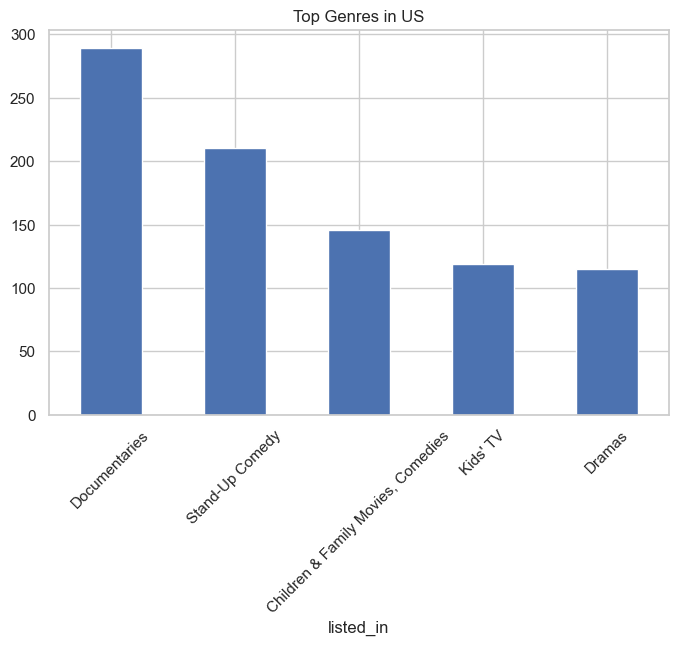

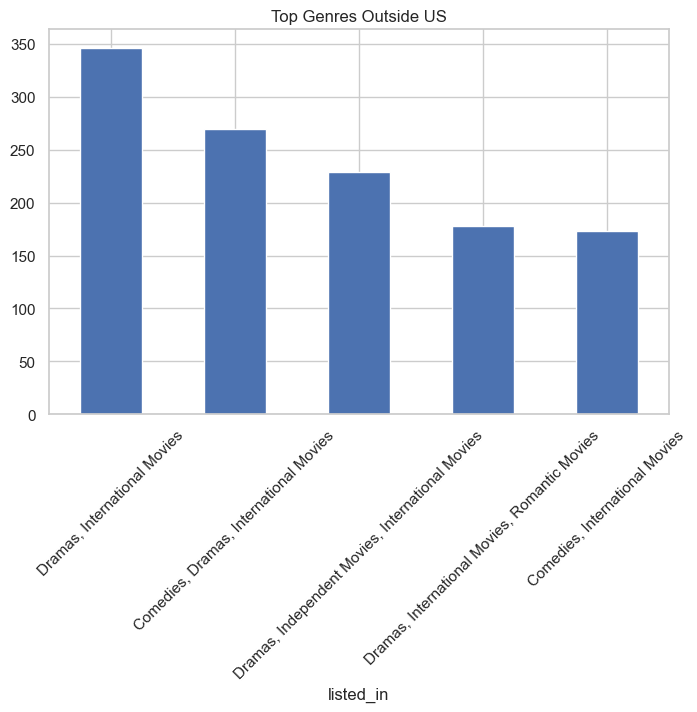

In [15]:
us = df[df['country'].str.contains("United States", na=False)]
non_us = df[~df['country'].str.contains("United States", na=False)]

us['listed_in'].value_counts().head(5).plot(kind='bar', figsize=(8,5))
plt.title("Top Genres in US")
plt.xticks(rotation=45)
plt.show()

non_us['listed_in'].value_counts().head(5).plot(kind='bar', figsize=(8,5))
plt.title("Top Genres Outside US")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1.The US market often emphasizes mainstream genres like Drama and Comedy.
#### 2.Other countries show more diversity, including regional and international genres.
## Q10. What genres are most popular in the last 3 years?

### Code:

In [16]:
recent = df[df['release_year'] >= df['release_year'].max() - 3]
recent['listed_in'].value_counts().head(10)

listed_in
Stand-Up Comedy                                      159
Documentaries                                        130
Dramas, International Movies                         124
Kids' TV                                             105
Dramas, Independent Movies, International Movies     101
Children & Family Movies                              97
Comedies, Dramas, International Movies                95
Children & Family Movies, Comedies                    73
Dramas, International Movies, Romantic Movies         72
Crime TV Shows, International TV Shows, TV Dramas     70
Name: count, dtype: int64

### Graph

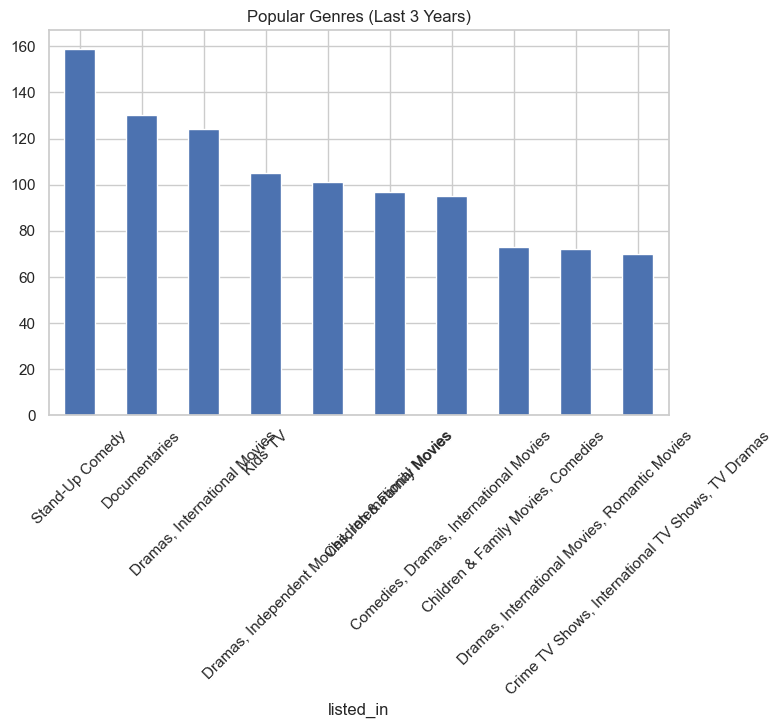

In [17]:
recent = df[df['release_year'] >= df['release_year'].max() - 3]

recent['listed_in'].value_counts().head(10).plot(
    kind='bar', figsize=(8,5)
)
plt.title("Popular Genres (Last 3 Years)")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1.Recent years highlight trending genres like Thrillers and Documentaries.
#### 2.Audience preferences shift over time, showing evolving content demand.
## Q11. Who are the top 10 directors with the most Netflix content?

### Code :

In [18]:
directors = df['director'].str.split(', ', expand=True).stack()
directors.value_counts().head(10)

Unknown                2634
Rajiv Chilaka            22
Jan Suter                21
RaÃºl Campos             19
Suhas Kadav              16
Marcus Raboy             16
Jay Karas                15
Cathy Garcia-Molina      13
Martin Scorsese          12
Jay Chapman              12
Name: count, dtype: int64

### graph:

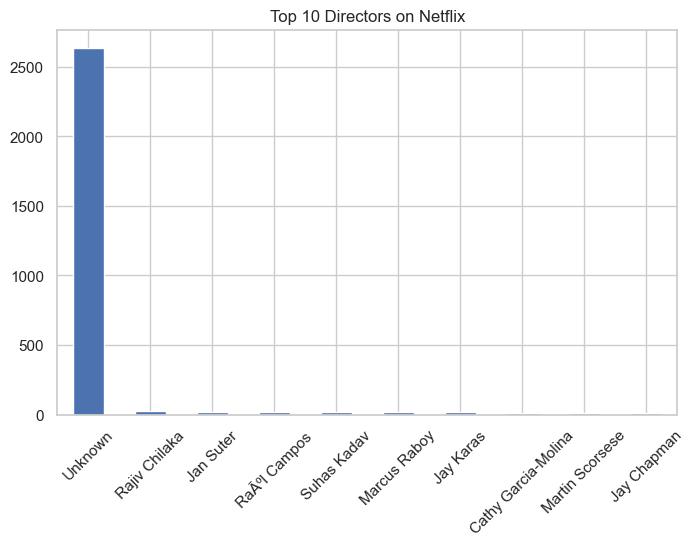

In [19]:
directors = df['director'].str.split(', ', expand=True).stack()
directors.value_counts().head(10).plot(
    kind='bar', figsize=(8,5))
plt.title("Top 10 Directors on Netflix")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1.A few directors consistently produce more content, indicating strong partnerships.
#### 2.These directors can be key assets for future collaborations.
## Q12. Which actors appear most frequently in Netflix shows?

### Code:

In [20]:
actors = df['cast'].str.split(', ', expand=True).stack()
actors.value_counts().head(10)

Unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Name: count, dtype: int64

### Graph:

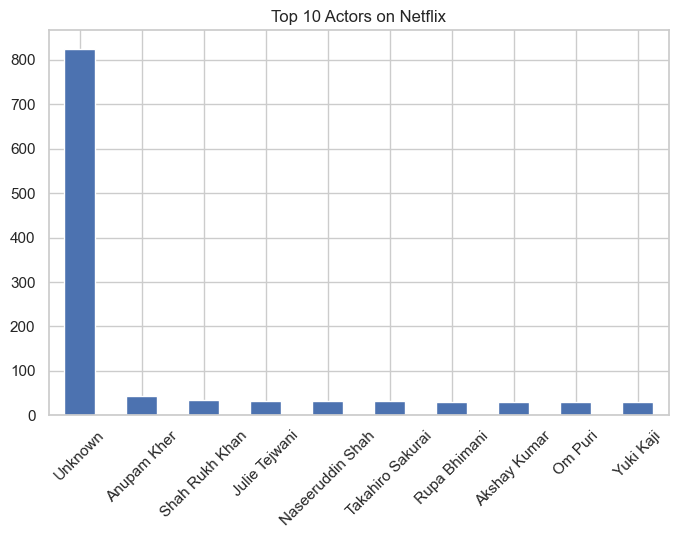

In [21]:
actors = df['cast'].str.split(', ', expand=True).stack()
actors.value_counts().head(10).plot(
    kind='bar', figsize=(8,5))
plt.title("Top 10 Actors on Netflix")
plt.xticks(rotation=45)
plt.show()

### Insights:
#### 1. Popular actors appear repeatedly, helping in audience retention.
#### 2. Frequent appearances indicate strong industry demand for certain actors.
## Q13. Which director-genre pairs are most frequent?

### code:

In [22]:
df[['director', 'listed_in']].value_counts().head(10)

director  listed_in                                             
Unknown   Kids' TV                                                  214
          International TV Shows, TV Dramas                         113
          Reality TV                                                 94
          Crime TV Shows, International TV Shows, TV Dramas          92
          Kids' TV, TV Comedies                                      91
          International TV Shows, Romantic TV Shows, TV Dramas       88
          Anime Series, International TV Shows                       83
          International TV Shows, Romantic TV Shows, TV Comedies     82
          Docuseries                                                 68
          TV Comedies                                                67
Name: count, dtype: int64

### Graph:

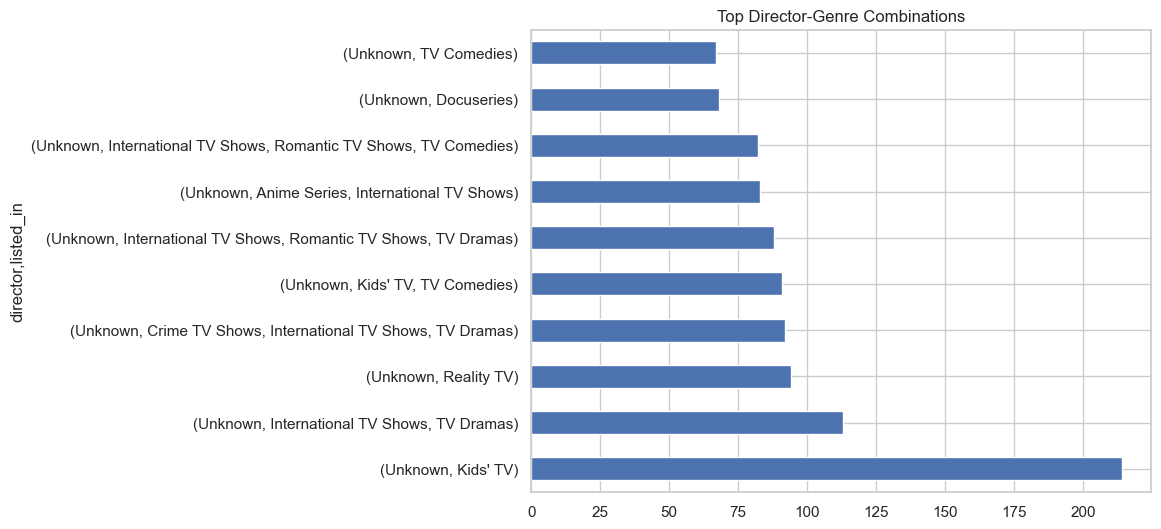

In [23]:
df[['director', 'listed_in']].value_counts().head(10).plot(
    kind='barh', figsize=(8,6))
plt.title("Top Director-Genre Combinations")
plt.show()

### Insights:
#### 1.Certain directors specialize in specific genres.
#### 2.Successful director-genre combinations can guide future production strategies.
## Q14. How many titles have unknown directors or cast members?

### Code:

In [5]:
print("Unknown Directors:", df[df['director'] == "Unknown"].shape[0])
print("Unknown Cast:", df[df['cast'] == "Unknown"].shape[0])

Unknown Directors: 2634
Unknown Cast: 825


### Graph :

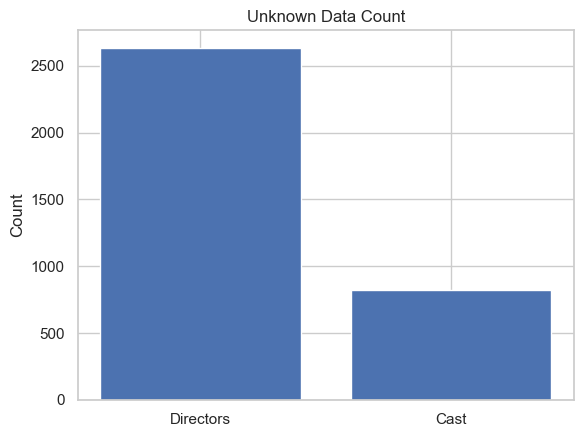

In [6]:
unknown_directors = df[df['director']=="Unknown"].shape[0]
unknown_cast = df[df['cast']=="Unknown"].shape[0]

plt.bar(['Directors', 'Cast'], [unknown_directors, unknown_cast])
plt.title("Unknown Data Count")
plt.ylabel("Count")
plt.show()

### Insights:
#### 1.A significant number of missing values may indicate incomplete data.
#### 2.These gaps can affect analysis accuracy and should be handled carefully.
## Q15. What is the average duration of Movies on Netflix?
### Code :

In [7]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')
print(movies['duration'].mean())

99.57718668407311


### Graph :

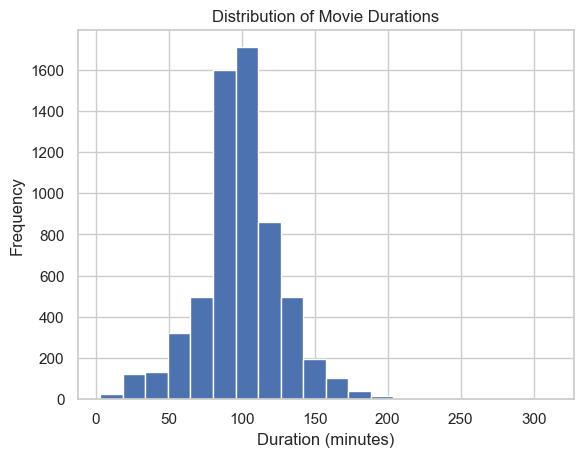

In [8]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

movies['duration'].plot(kind='hist', bins=20)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.show()

### Insights:
#### 1.The average movie duration typically falls around standard viewing time (~90–120 minutes).
#### 2.This reflects audience preference for moderate-length content.
## Q16. What’s the most common number of seasons for TV shows?
### Code:

In [9]:
tv = df[df['type'] == 'TV Show'].copy()
tv['duration'] = tv['duration'].str.replace(' Seasons', '')
tv['duration'] = tv['duration'].str.replace(' Season', '')
tv['duration'] = pd.to_numeric(tv['duration'], errors='coerce')
tv['duration'].value_counts().head()

duration
1    1793
2     425
3     199
4      95
5      65
Name: count, dtype: int64

### Graph:

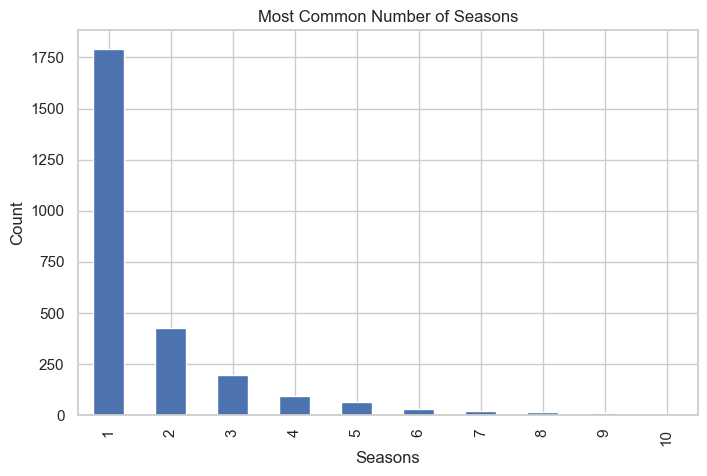

In [10]:
tv = df[df['type'] == 'TV Show'].copy()

tv['duration'] = tv['duration'].str.replace(' Seasons', '')
tv['duration'] = tv['duration'].str.replace(' Season', '')
tv['duration'] = pd.to_numeric(tv['duration'], errors='coerce')

tv['duration'].value_counts().head(10).plot(
    kind='bar', figsize=(8,5)
)
plt.title("Most Common Number of Seasons")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.show()

### Insights:
#### 1.Most TV shows have 1–2 seasons, indicating shorter lifecycle.
#### 2.Longer series are fewer, suggesting higher production cost or risk.
## Q17. Is there a trend in movie durations over the years?
### Code:

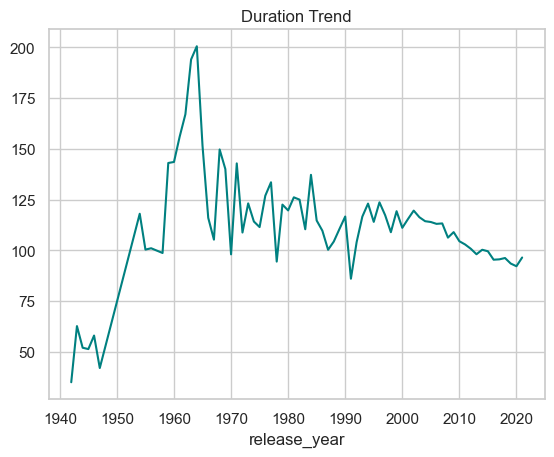

In [11]:
movies.groupby('release_year')['duration'].mean().plot(color='teal')
plt.title("Duration Trend")
plt.show()

### Insights:
#### 1.Movie durations remain relatively stable over time.
#### 2.Slight variations may reflect changing viewer attention spans.
## Q18. In which months does Netflix add the most content?
### Code+Graph:

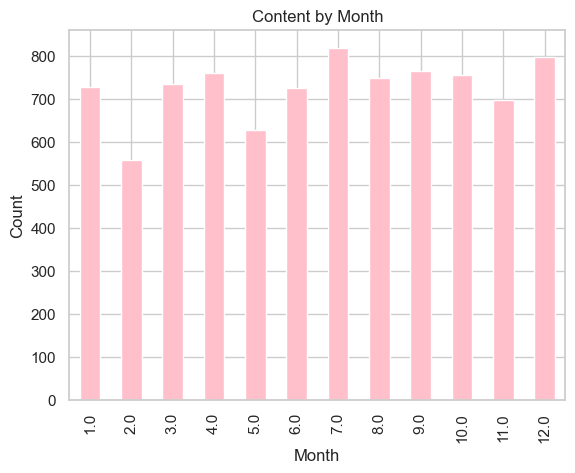

In [12]:
df['month_added'] = pd.to_numeric(df['month_added'], errors='coerce')
month_data = df['month_added'].value_counts().sort_index()
month_data.plot(kind='bar', color='pink')
plt.title("Content by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

### Insights:
#### 1. Certain months show higher content addition, likely due to holiday seasons.
#### 2.Strategic releases align with peak viewer activity periods.
## Q19. How does the genre distribution vary across different years?
### Code+Graph:

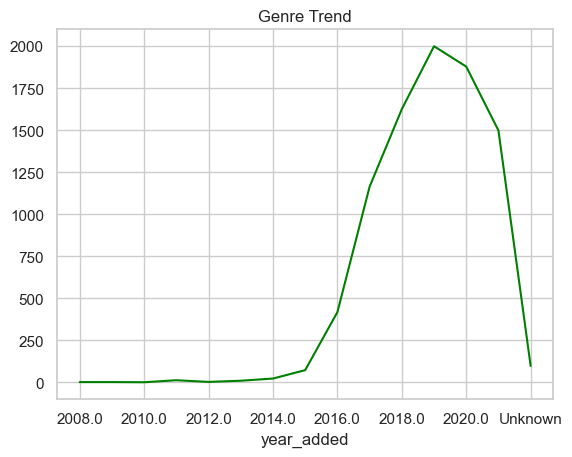

In [13]:
df.groupby('year_added')['listed_in'].count().plot(color='green')
plt.title("Genre Trend")
plt.show()

### Insights:
#### 1. Genre distribution increases over time with more content diversity.
#### 2.Netflix expands its catalog to cater to changing audience interests.
## Q20. Which countries produce the most content in each genre?
### Code:

In [14]:
df[['country','listed_in']].value_counts().head(10)

country        listed_in                                       
United States  Documentaries                                       249
               Stand-Up Comedy                                     209
India          Comedies, Dramas, International Movies              120
               Dramas, International Movies                        118
               Dramas, Independent Movies, International Movies    108
United States  Children & Family Movies, Comedies                   90
               Dramas                                               88
               Comedies                                             84
               Children & Family Movies                             80
               Kids' TV                                             77
Name: count, dtype: int64

### Graph:

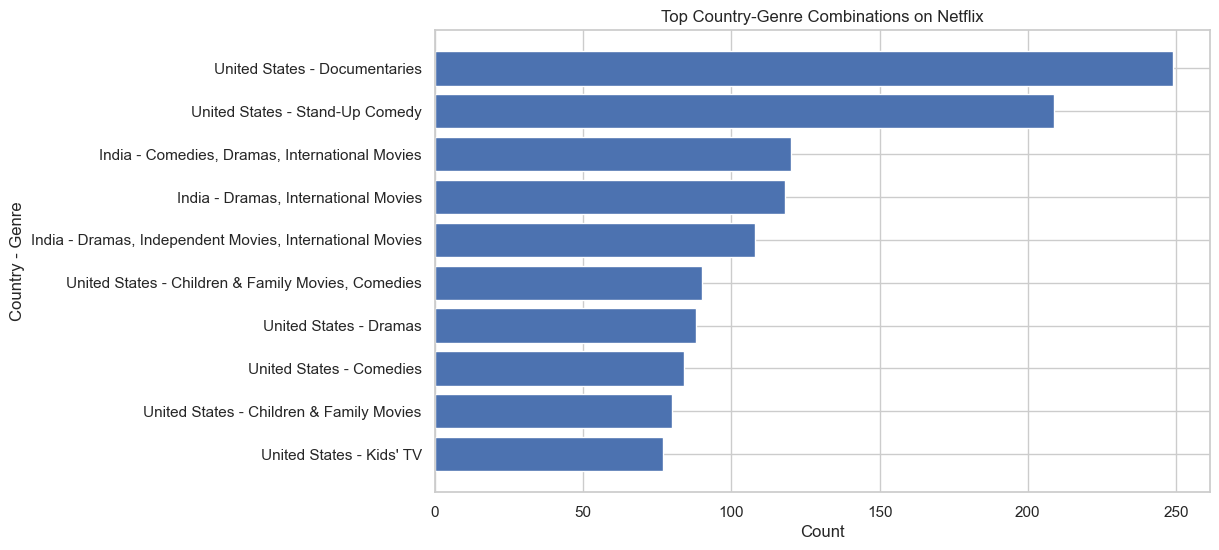

In [15]:
top_data = df[['country','listed_in']].value_counts().head(10)
top_data = top_data.reset_index(name='count')
top_data['label'] = top_data['country'] + " - " + top_data['listed_in']
plt.figure(figsize=(10,6))
plt.barh(top_data['label'], top_data['count'])
plt.title("Top Country-Genre Combinations on Netflix")
plt.xlabel("Count")
plt.ylabel("Country - Genre")
plt.gca().invert_yaxis() 
plt.show()

### Insights:
#### 1.Certain countries dominate specific genres (e.g., US in Drama).
#### 2.Helps Netflix focus on regional strengths for content production.
## - ASSIGNMENT BY ZAHRA JAFRI BCA DS 17 , THANK YOU